In [480]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [481]:
df = pd.read_csv('/content/joined Labeled.csv', na_values=' ?')
df.head()

,Subject,LOGIMEM,DIGIF,DIGIFLEN,DIGIB,DIGIBLEN,ANIMALS,VEG,TRAILA,TRAILARR,...,judgment,memory,orient,perscare,apoe,sumbox,height,weight,Target,dx1
0,OAS30019,9.0,8.0,7.0,5.0,4.0,23.0,15.0,31.0,0.0,...,0.0,0.5,0.5,0.0,23.0,1.0,63.0,190.0,1,AD Dementia
1,OAS30019,7.0,7.0,6.0,7.0,5.0,15.0,11.0,32.0,0.0,...,0.5,0.5,0.0,0.0,23.0,2.0,64.0,189.0,1,AD Dementia
2,OAS30022,11.0,8.0,6.0,4.0,3.0,13.0,10.0,40.0,NaN,...,2.0,1.0,1.0,1.0,34.0,8.0,69.0,183.0,1,AD Dementia
3,OAS30022,4.0,11.0,8.0,4.0,3.0,7.0,5.0,45.0,0.0,...,2.0,2.0,2.0,1.0,34.0,10.0,69.0,192.0,1,AD Dementia
4,OAS30022,5.0,8.0,6.0,3.0,3.0,13.0,5.0,51.0,0.0,...,2.0,1.0,1.0,1.0,34.0,8.0,69.0,198.0,1,AD Dementia


In [482]:
df.isna().sum()

Subject                       0
LOGIMEM                       9
DIGIF                         2
DIGIFLEN                      2
DIGIB                         8
DIGIBLEN                      8
ANIMALS                       7
VEG                           9
TRAILA                       17
TRAILARR                    503
TRAILALI                    503
TRAILB                      171
TRAILBRR                    631
TRAILBLI                    631
WAIS                         77
MEMUNITS                     12
MEMTIME                      17
BOSTON                       10
IntraCranialVol             122
lhCortexVol                 122
rhCortexVol                 122
CortexVol                   122
SubCortGrayVol              122
TotalGrayVol                122
SupraTentorialVol           122
lhCorticalWhiteMatterVol    122
rhCorticalWhiteMatterVol    122
CorticalWhiteMatterVol      122
mmse                         64
ageAtEntry                    0
commun                       10
homehobb

In [483]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('dx1', 1), df['dx1'],
                                                   test_size=0.2, random_state=1)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  """Entry point for launching an IPython kernel.


In [484]:
from sklearn.impute import KNNImputer

In [485]:
knn = KNNImputer(n_neighbors=2, add_indicator=True)

In [486]:
num = [col for col in X_train.columns if X_train[col].dtypes != 'O']

In [487]:
X_train[num].head()

,LOGIMEM,DIGIF,DIGIFLEN,DIGIB,DIGIBLEN,ANIMALS,VEG,TRAILA,TRAILARR,TRAILALI,...,homehobb,judgment,memory,orient,perscare,apoe,sumbox,height,weight,Target
2908,13.0,7.0,6.0,6.0,4.0,23.0,12.0,37.0,1.0,24.0,...,0.0,0.0,0.0,0.0,0.0,44.0,0.0,72.0,184.0,0
2595,22.0,10.0,2.0,8.0,1.0,5.0,18.0,36.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,33.0,0.0,66.0,194.0,0
1381,23.0,6.0,6.0,5.0,4.0,16.0,12.0,41.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,33.0,0.0,62.0,123.0,0
81,9.0,8.0,6.0,2.0,2.0,14.0,19.0,57.0,6.0,24.0,...,0.5,1.0,1.0,1.0,0.0,34.0,4.0,65.0,172.0,1
151,3.0,6.0,5.0,4.0,3.0,12.0,8.0,28.0,0.0,24.0,...,0.5,0.5,0.5,0.5,0.0,34.0,2.5,65.0,184.0,1


In [488]:
knn.fit(X_train[num])

KNNImputer(add_indicator=True, n_neighbors=2)

In [489]:
knn.transform(X_train[num])

array([[13.,  7.,  6., ...,  0.,  0.,  0.],
       [22., 10.,  2., ...,  0.,  0.,  0.],
       [23.,  6.,  6., ...,  0.,  0.,  0.],
       ...,
       [19.,  6.,  6., ...,  0.,  0.,  0.],
       [12.,  8.,  6., ...,  0.,  0.,  0.],
       [15.,  8.,  7., ...,  0.,  1.,  1.]])

In [490]:
pd.DataFrame(knn.transform(X_train[num])).head()

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
0,13.0,7.0,6.0,6.0,4.0,23.0,12.0,37.0,1.0,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,22.0,10.0,2.0,8.0,1.0,5.0,18.0,36.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,23.0,6.0,6.0,5.0,4.0,16.0,12.0,41.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,9.0,8.0,6.0,2.0,2.0,14.0,19.0,57.0,6.0,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,6.0,5.0,4.0,3.0,12.0,8.0,28.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [491]:
X_test[num].isna().sum()

LOGIMEM                       3
DIGIF                         1
DIGIFLEN                      1
DIGIB                         1
DIGIBLEN                      1
ANIMALS                       1
VEG                           2
TRAILA                        2
TRAILARR                    102
TRAILALI                    102
TRAILB                       30
TRAILBRR                    127
TRAILBLI                    127
WAIS                         24
MEMUNITS                      4
MEMTIME                       5
BOSTON                        3
IntraCranialVol              18
lhCortexVol                  18
rhCortexVol                  18
CortexVol                    18
SubCortGrayVol               18
TotalGrayVol                 18
SupraTentorialVol            18
lhCorticalWhiteMatterVol     18
rhCorticalWhiteMatterVol     18
CorticalWhiteMatterVol       18
mmse                         14
ageAtEntry                    0
commun                        1
homehobb                      1
judgment

In [492]:
knn.transform(X_test[num])

array([[14., 11.,  8., ...,  0.,  1.,  1.],
       [11., 11.,  8., ...,  0.,  1.,  1.],
       [13., 10.,  8., ...,  0.,  0.,  0.],
       ...,
       [18.,  7.,  6., ...,  0.,  0.,  0.],
       [17.,  7.,  6., ...,  0.,  0.,  0.],
       [15.,  6.,  5., ...,  0.,  0.,  0.]])

In [493]:
pd.DataFrame(knn.transform(X_test[num])).isna().sum().sum()

0

In [494]:
pd.DataFrame(knn.transform(X_train[num])).isna().sum().sum()

0

In [495]:
pd.DataFrame(knn.transform(X_train[num])).to_csv(r'/content/2 neighbor_Train.csv', index=False)

In [496]:
pd.DataFrame(knn.transform(X_test[num])).to_csv(r'/content/2 neighbor_Test.csv', index=False)

***Analyzing the performence of imputed dataset.***

In [497]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=2)

In [498]:
df = pd.read_csv('/content/2 neighbor.csv', na_values=' ?')
df.head()

,LOGIMEM,DIGIF,DIGIFLEN,DIGIB,DIGIBLEN,ANIMALS,VEG,TRAILA,TRAILARR,TRAILALI,...,homehobb,judgment,memory,orient,perscare,apoe,sumbox,height,weight,Target
0,13.0,7,6.0,6.0,4.0,23.0,12.0,37.0,1.0,24.0,...,0.0,0.0,0.0,0.0,0.0,44.0,0.0,72.0,184.0,0
1,22.0,10,2.0,8.0,1.0,5.0,18.0,36.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,33.0,0.0,66.0,194.0,0
2,23.0,6,6.0,5.0,4.0,16.0,12.0,41.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,33.0,0.0,62.0,123.0,0
3,9.0,8,6.0,2.0,2.0,14.0,19.0,57.0,6.0,24.0,...,0.5,1.0,1.0,1.0,0.0,34.0,4.0,65.0,172.0,1
4,3.0,6,5.0,4.0,3.0,12.0,8.0,28.0,0.0,24.0,...,0.5,0.5,0.5,0.5,0.0,34.0,2.5,65.0,184.0,1


In [499]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTE

In [500]:
from sklearn.model_selection import train_test_split

In [501]:
X = df.drop(['Target'], axis='columns')
y = df.Target

In [502]:
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [503]:


# smk = SMOTETomek(random_state=42)
# X_res,y_res=smk.fit_sample(X,y)

In [504]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [505]:
len(X_train)

8992

In [506]:

len(X_test)

2248

In [507]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [508]:
knn.score(X_test, y_test)

0.8723309608540926

In [509]:
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[399,  23,  11,  25,   5],
       [ 36, 387,  12,  10,   5],
       [  6,  14, 419,   2,   2],
       [ 56,  40,  12, 352,   5],
       [ 11,   4,   3,   5, 404]])

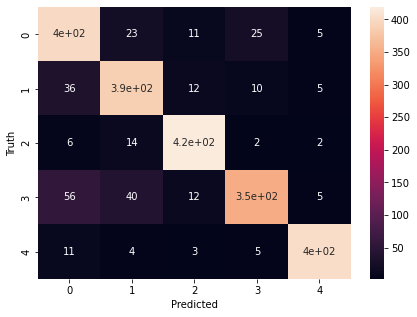

In [510]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize=(7,5))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.savefig("2 neighbor.jpg")

In [511]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82       463
           1       0.83      0.86      0.84       450
           2       0.92      0.95      0.93       443
           3       0.89      0.76      0.82       465
           4       0.96      0.95      0.95       427

    accuracy                           0.87      2248
   macro avg       0.88      0.87      0.87      2248
weighted avg       0.88      0.87      0.87      2248



In [512]:
#import necessary libraries
from sklearn.metrics import mean_squared_error
from math import sqrt

#calculate RMSE
sqrt(mean_squared_error(y_test, y_pred)) 

0.8067222023371937